<a href="https://colab.research.google.com/github/Vivek-ML001/NLP-Preprocessing-Pipeline-Movie-Reviews-/blob/main/Dhurandar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NLP Preprocessing Pipeline (Movie Reviews)
I have chosen the **Dhurandar movie** reviews dataset (≈1099 samples) and I have  task is to perform **full NLP preprocessing**

## Import Liblary

In [95]:
import pandas as pd
import nltk
import string
string.punctuation
from nltk import word_tokenize
from nltk import sent_tokenize

## Load dataset

In [96]:
df = pd.read_csv("/content/Dhurandhar_IMDb_Reviews.csv")

In [97]:
df.head()

,rating,title,review,username,date,helpful_yes,helpful_no
0,9,"A blood-crawling, gut wrenching, exhilarating ...",This is how I want to see a spy/espionage movi...,aniruddhabonny,"Dec 6, 2025",354.0,53.0
1,9,The Best Film Of 2025 In Bollywood,Since the beginning Movie pace and Story hook ...,Premgupta1048,"Dec 6, 2025",266.0,48.0
2,9,"After a long time, a good espionage movie","Well, well, well... Pathan, War 2, Singham, an...",gk303007,"Dec 7, 2025",248.0,50.0
3,10,🔥🔥🔥🔥,DHURANDHAR EXPERIENCE A spy action movie with ...,skmenon1993,"Dec 7, 2025",223.0,48.0
4,10,Reasons you should watch it in cinemas,The movie absolutely stands on top of other Bo...,DevanshD-14,"Dec 7, 2025",173.0,52.0


In [98]:
df["review"][0]

'This is how I want to see a spy/espionage movie in Indian cinema. Excellent world and character building, with outstanding set pieces. Every single actor played their roles to perfection! Askhay Khanna stands out the most. However, as others mentioned, the role of Ranveer was not to stand out in the first place, and the director and actor executed'

In [99]:
df.shape


(1099, 7)

In [100]:
df = df.drop(columns=["date","helpful_yes","helpful_no","username","title"])

In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1099 entries, 0 to 1098
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   rating  1099 non-null   int64 
 1   review  1099 non-null   object
dtypes: int64(1), object(1)
memory usage: 17.3+ KB


## Convert into Lowercase / Uppercase

In [102]:
df['review'] = df['review'].astype(str).str.lower()

In [103]:
df.head(2)

,rating,review
0,9,this is how i want to see a spy/espionage movi...
1,9,since the beginning movie pace and story hook ...


In [149]:
df1 =  df["review"].astype(str).str.upper()

In [151]:
df1.head()

,review
0,THIS IS HOW I WANT TO SEE A SPY ESPIONAGE MOVI...
1,SINCE THE BEGINNING MOVIE PACE AND STORY HOOK ...
2,WELL WELL WELL PATHAN WAR 2 SINGHAM AN...
3,DHURANDHAR EXPERIENCE A SPY ACTION MOVIE WITH ...
4,THE MOVIE ABSOLUTELY STANDS ON TOP OF OTHER BO...


## Tokenize

In [104]:
def word_tokenizer(text):
    if isinstance(text, str):
        return nltk.word_tokenize(text)
    return []

def sentence_tokenizer(text):
    if isinstance(text, str):
        return nltk.sent_tokenize(text)
    return []

In [105]:
df['word_tokens'] = df['review'].apply(word_tokenizer)
df['sentence_tokens'] = df['review'].apply(sentence_tokenizer)

In [106]:
df.head()

,rating,review,word_tokens,sentence_tokens
0,9,this is how i want to see a spy/espionage movi...,"[this, is, how, i, want, to, see, a, spy/espio...",[this is how i want to see a spy/espionage mov...
1,9,since the beginning movie pace and story hook ...,"[since, the, beginning, movie, pace, and, stor...",[since the beginning movie pace and story hook...
2,9,"well, well, well... pathan, war 2, singham, an...","[well, ,, well, ,, well, ..., pathan, ,, war, ...","[well, well, well... pathan, war 2, singham, a..."
3,10,dhurandhar experience a spy action movie with ...,"[dhurandhar, experience, a, spy, action, movie...",[dhurandhar experience a spy action movie with...
4,10,the movie absolutely stands on top of other bo...,"[the, movie, absolutely, stands, on, top, of, ...",[the movie absolutely stands on top of other b...


In [107]:
df["word_count"] = df["word_tokens"].apply(len)
df["sentence_count"] = df["sentence_tokens"].apply(len)

In [108]:
df.head()

,rating,review,word_tokens,sentence_tokens,word_count,sentence_count
0,9,this is how i want to see a spy/espionage movi...,"[this, is, how, i, want, to, see, a, spy/espio...",[this is how i want to see a spy/espionage mov...,67,5
1,9,since the beginning movie pace and story hook ...,"[since, the, beginning, movie, pace, and, stor...",[since the beginning movie pace and story hook...,111,7
2,9,"well, well, well... pathan, war 2, singham, an...","[well, ,, well, ,, well, ..., pathan, ,, war, ...","[well, well, well... pathan, war 2, singham, a...",202,12
3,10,dhurandhar experience a spy action movie with ...,"[dhurandhar, experience, a, spy, action, movie...",[dhurandhar experience a spy action movie with...,197,10
4,10,the movie absolutely stands on top of other bo...,"[the, movie, absolutely, stands, on, top, of, ...",[the movie absolutely stands on top of other b...,109,3


## Frequency Count

In [144]:
from nltk.probability import FreqDist

In [145]:
all_words = [word for tokens in df['word_tokens'] for word in tokens]

In [146]:
fdist = FreqDist(all_words)

print(fdist.most_common(10))

[(',', 6111), ('the', 6104), ('.', 5836), ('and', 4136), ('a', 2476), ('is', 2069), ('of', 1844), ('to', 1549), ('it', 1276), ('in', 1207)]


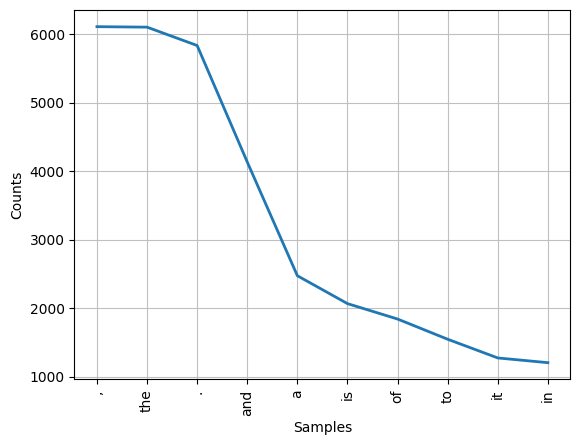

In [147]:
import matplotlib.pyplot as plt
fdist.plot(10)
plt.show()

## Punctuation remove

In [109]:
exclude = string.punctuation
def remove_punc(df):
  for char in exclude:
    df = df.replace(char," ")
  return df

In [110]:
 df['review'] = df['review'].apply(remove_punc)

In [111]:
df.head(2)

,rating,review,word_tokens,sentence_tokens,word_count,sentence_count
0,9,this is how i want to see a spy espionage movi...,"[this, is, how, i, want, to, see, a, spy/espio...",[this is how i want to see a spy/espionage mov...,67,5
1,9,since the beginning movie pace and story hook ...,"[since, the, beginning, movie, pace, and, stor...",[since the beginning movie pace and story hook...,111,7


## Remove HTML</>

In [112]:
import re
def remove_html(text):
    html_pattern = re.compile('<.*?>')
    return html_pattern.sub(r'', text)

In [113]:
df["review"] = df["review"].apply(remove_html)

In [114]:
df.head(2)

,rating,review,word_tokens,sentence_tokens,word_count,sentence_count
0,9,this is how i want to see a spy espionage movi...,"[this, is, how, i, want, to, see, a, spy/espio...",[this is how i want to see a spy/espionage mov...,67,5
1,9,since the beginning movie pace and story hook ...,"[since, the, beginning, movie, pace, and, stor...",[since the beginning movie pace and story hook...,111,7


## Remove URL (https://)

In [115]:
def remove_url(text):
    url_pattern = re.compile(r'https?://\S+|www\.\S+')
    return url_pattern.sub(r'', text)

In [116]:
df["review"] = df["review"].apply(remove_url)

In [117]:
df.head(2)

,rating,review,word_tokens,sentence_tokens,word_count,sentence_count
0,9,this is how i want to see a spy espionage movi...,"[this, is, how, i, want, to, see, a, spy/espio...",[this is how i want to see a spy/espionage mov...,67,5
1,9,since the beginning movie pace and story hook ...,"[since, the, beginning, movie, pace, and, stor...",[since the beginning movie pace and story hook...,111,7


## Remove Stopwords

In [118]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [119]:
def remove_stopwords(text):
    if not isinstance(text, str):
        return ""

    words = word_tokenize(text)
    filtered = [w for w in words if w.lower() not in stop_words]

    return " ".join(filtered)

In [120]:
df['clean_review'] = df['review'].apply(remove_stopwords)

In [121]:
df.head(2)

,rating,review,word_tokens,sentence_tokens,word_count,sentence_count,clean_review
0,9,this is how i want to see a spy espionage movi...,"[this, is, how, i, want, to, see, a, spy/espio...",[this is how i want to see a spy/espionage mov...,67,5,want see spy espionage movie indian cinema exc...
1,9,since the beginning movie pace and story hook ...,"[since, the, beginning, movie, pace, and, stor...",[since the beginning movie pace and story hook...,111,7,since beginning movie pace story hook much for...


In [122]:
df["clean_review_word"] = df["clean_review"].apply(word_tokenizer)
df["clean_review_sentence"] = df["clean_review"].apply(sentence_tokenizer)

In [123]:
df["clean_review_word_count"] = df["clean_review_word"].apply(len)
df["clean_review_sentence_count"] = df["clean_review_sentence"].apply(len)

In [124]:
df.head(2)

,rating,review,word_tokens,sentence_tokens,word_count,sentence_count,clean_review,clean_review_word,clean_review_sentence,clean_review_word_count,clean_review_sentence_count
0,9,this is how i want to see a spy espionage movi...,"[this, is, how, i, want, to, see, a, spy/espio...",[this is how i want to see a spy/espionage mov...,67,5,want see spy espionage movie indian cinema exc...,"[want, see, spy, espionage, movie, indian, cin...",[want see spy espionage movie indian cinema ex...,34,1
1,9,since the beginning movie pace and story hook ...,"[since, the, beginning, movie, pace, and, stor...",[since the beginning movie pace and story hook...,111,7,since beginning movie pace story hook much for...,"[since, beginning, movie, pace, story, hook, m...",[since beginning movie pace story hook much fo...,58,1


## Remove_emoji

In [125]:

def remove_emoji(string):
    emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticons
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                           u"\U0001F680-\U0001F6FF"  # transport & map symbols
                           u"\U0001F1E0-\U0001F1FF"  # flags
                           u"\U00002702-\U000027B0"  # dingbats
                           u"\U000024C2-\U0001F251"  # enclosed characters
                           u"\U0001F900-\U0001F9FF"  # supplemental symbols
                           u"\U0001FA00-\U0001FA6F"  # chess symbols
                           u"\U0001FA70-\U0001FAFF"  # symbols and pictographs extended
                           u"\U00002500-\U00002BEF"  # misc symbols
                           "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', string)


In [127]:
df["review"] = df["review"].apply(lambda text: remove_emoji(str(text)))
df.head(2)

,rating,review,word_tokens,sentence_tokens,word_count,sentence_count,clean_review,clean_review_word,clean_review_sentence,clean_review_word_count,clean_review_sentence_count
0,9,this is how i want to see a spy espionage movi...,"[this, is, how, i, want, to, see, a, spy/espio...",[this is how i want to see a spy/espionage mov...,67,5,want see spy espionage movie indian cinema exc...,"[want, see, spy, espionage, movie, indian, cin...",[want see spy espionage movie indian cinema ex...,34,1
1,9,since the beginning movie pace and story hook ...,"[since, the, beginning, movie, pace, and, stor...",[since the beginning movie pace and story hook...,111,7,since beginning movie pace story hook much for...,"[since, beginning, movie, pace, story, hook, m...",[since beginning movie pace story hook much fo...,58,1


In [128]:
test = "great movie 😊🎬🔥"
print(remove_emoji(test))
print(df["review"].head())

great movie 
0    this is how i want to see a spy espionage movi...
1    since the beginning movie pace and story hook ...
2    well  well  well    pathan  war 2  singham  an...
3    dhurandhar experience a spy action movie with ...
4    the movie absolutely stands on top of other bo...
Name: review, dtype: object


## Pos_tag ( Part of speech )

In [139]:
import nltk
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [140]:
def pos_tagger(token):
  if isinstance(token, list):
    return nltk.pos_tag(token)
  return []


In [141]:
df['pos_tags'] = df['word_tokens'].apply(pos_tagger)

In [142]:
df.head(2)

,rating,review,word_tokens,sentence_tokens,word_count,sentence_count,clean_review,clean_review_word,clean_review_sentence,clean_review_word_count,clean_review_sentence_count,pos_tags
0,9,this is how i want to see a spy espionage movi...,"[this, is, how, i, want, to, see, a, spy/espio...",[this is how i want to see a spy/espionage mov...,67,5,want see spy espionage movie indian cinema exc...,"[want, see, spy, espionage, movie, indian, cin...",[want see spy espionage movie indian cinema ex...,34,1,"[(this, DT), (is, VBZ), (how, WRB), (i, JJ), (..."
1,9,since the beginning movie pace and story hook ...,"[since, the, beginning, movie, pace, and, stor...",[since the beginning movie pace and story hook...,111,7,since beginning movie pace story hook much for...,"[since, beginning, movie, pace, story, hook, m...",[since beginning movie pace story hook much fo...,58,1,"[(since, IN), (the, DT), (beginning, NN), (mov..."


In [143]:
df["pos_tags"][0]

[('this', 'DT'),
 ('is', 'VBZ'),
 ('how', 'WRB'),
 ('i', 'JJ'),
 ('want', 'VBP'),
 ('to', 'TO'),
 ('see', 'VB'),
 ('a', 'DT'),
 ('spy/espionage', 'NN'),
 ('movie', 'NN'),
 ('in', 'IN'),
 ('indian', 'JJ'),
 ('cinema', 'NN'),
 ('.', '.'),
 ('excellent', 'JJ'),
 ('world', 'NN'),
 ('and', 'CC'),
 ('character', 'NN'),
 ('building', 'NN'),
 (',', ','),
 ('with', 'IN'),
 ('outstanding', 'JJ'),
 ('set', 'NN'),
 ('pieces', 'NNS'),
 ('.', '.'),
 ('every', 'DT'),
 ('single', 'JJ'),
 ('actor', 'NN'),
 ('played', 'VBD'),
 ('their', 'PRP$'),
 ('roles', 'NNS'),
 ('to', 'TO'),
 ('perfection', 'NN'),
 ('!', '.'),
 ('askhay', 'NN'),
 ('khanna', 'VB'),
 ('stands', 'VBZ'),
 ('out', 'RP'),
 ('the', 'DT'),
 ('most', 'RBS'),
 ('.', '.'),
 ('however', 'RB'),
 (',', ','),
 ('as', 'IN'),
 ('others', 'NNS'),
 ('mentioned', 'VBN'),
 (',', ','),
 ('the', 'DT'),
 ('role', 'NN'),
 ('of', 'IN'),
 ('ranveer', 'NN'),
 ('was', 'VBD'),
 ('not', 'RB'),
 ('to', 'TO'),
 ('stand', 'VB'),
 ('out', 'RP'),
 ('in', 'IN'),
 ('the